## Scalings

Here we check how the code behaves as the problem size is increased.

In [1]:
import jax_rmhd as jr
from typing import NamedTuple, Tuple
import jax
from jax import jit
import jax.numpy as jnp
import jax.numpy.fft as ft
from functools import partial
import matplotlib.pyplot as plt
import orbax.checkpoint as ocp
import os
from jax_rmhd.timestepping import block_of_steps
import timeit

In [ ]:
#parameters
Lx = Ly = 2.0*jnp.pi
nupar = 1e-4
dt = 0.01
t = 0.0
nblock = 50
cfl_safety=1.0 #this is pretty aggressive
visc=1e-9
res=1e-9
hyper=3

In [3]:
resolutions = [32,64,128,256,512,1024,2048]
results= []

for n in resolutions:
    x = jnp.linspace(0, Lx, n, endpoint=False)
    y = jnp.linspace(0, Ly, n, endpoint=False)
    x_grid = x.reshape(-1,1)
    y_grid = y.reshape(1,-1)

    #setting fields to zero: we just check scalings of the code with no effect from the physics
    phi = jnp.zeros_like(x_grid)+ jnp.zeros_like(y_grid)
    psi = jnp.zeros_like(x_grid)+ jnp.zeros_like(y_grid)

    #fft
    phik=ft.rfft2(phi)
    psik=ft.rfft2(psi)
    params=jr.Parameters(nx=n,ny=n,Lx=Lx,Ly=Ly,visc=visc,res=res,hyper=hyper,cfl_safety=cfl_safety)
    kgrid = jr.setup_kgrids(params)
    state = jr.SimulationState(t=0.0,fields=jr.Fields(phik,psik))
    #warmup jit
    block = lambda: jax.block_until_ready(block_of_steps(state, kgrid, params, nblock))
    _ = jax.block_until_ready(block_of_steps(state, kgrid, params, nblock))
    raw_times=jnp.array(timeit.repeat(block,number=1,repeat=10))
    results.append((jnp.mean(raw_times),jnp.std(raw_times)))

---COMPILING block_of_steps---
---COMPILING rk_advance---
---COMPILING block_of_steps---
---COMPILING rk_advance---
---COMPILING block_of_steps---
---COMPILING rk_advance---
---COMPILING block_of_steps---
---COMPILING rk_advance---
---COMPILING block_of_steps---
---COMPILING rk_advance---
---COMPILING block_of_steps---
---COMPILING rk_advance---
---COMPILING block_of_steps---
---COMPILING rk_advance---


Text(300.0, 0.003, '$\\propto n^2 log(n)$')

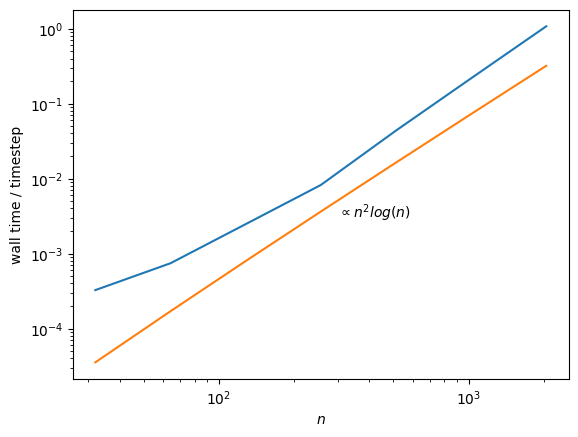

In [4]:
resultarr=jnp.array(results)/nblock
resolutionarr=jnp.array(resolutions)
plt.loglog(resolutionarr,resultarr[:,0])
plt.loglog(resolutionarr,1e-8*resolutionarr**2 * jnp.log(resolutionarr))
plt.xlabel(r'$n$')
plt.ylabel(r'wall time / timestep')
plt.text(3e2,3e-3,r'$\propto n^2 log(n)$')

The scaling for large n follows the expected scaling for 2D FFT (shown in orange).

Now let's see check how things change as we vary `nblock`. The reason for doing this is that depending on algorithm the XLA compiler can sometimes fuse across timesteps, improving performance. In our case, it does not seem like this is possible, but this could be checked on different machines.

In [5]:
n=256

x = jnp.linspace(0, Lx, n, endpoint=False)
y = jnp.linspace(0, Ly, n, endpoint=False)
x_grid = x.reshape(-1,1)
y_grid = y.reshape(1,-1)

#setting fields to zero: we just check scalings of the code with no effect from the physics
phi = jnp.zeros_like(x_grid)+ jnp.zeros_like(y_grid)
psi = jnp.zeros_like(x_grid)+ jnp.zeros_like(y_grid)

#fft
phik=ft.rfft2(phi)
psik=ft.rfft2(psi)
params=jr.Parameters(nx=n,ny=n,Lx=Lx,Ly=Ly,visc=visc,res=res,hyper=hyper,cfl_safety=cfl_safety)
kgrid = jr.setup_kgrids(params)
state = jr.SimulationState(t=0.0,fields=jr.Fields(phik,psik))

blocklengths = [1, 5, 10, 50, 100, 200, 500, 1000]
results = []

for nb in blocklengths:

    block = lambda: jax.block_until_ready(block_of_steps(state, kgrid, params, nb))
    #warm up jit
    _ = jax.block_until_ready(block_of_steps(state, kgrid, params, nb))
    _ = jax.block_until_ready(block_of_steps(state, kgrid, params, nb))
    raw_times=jnp.array(timeit.repeat(block,number=1,repeat=10))
    results.append((jnp.mean(raw_times)/nb,jnp.std(raw_times)/nb))

    
resultarr=jnp.array(results)
nbarr=jnp.array(blocklengths)


---COMPILING block_of_steps---
---COMPILING rk_advance---
---COMPILING block_of_steps---
---COMPILING block_of_steps---
---COMPILING block_of_steps---
---COMPILING block_of_steps---
---COMPILING block_of_steps---
---COMPILING block_of_steps---
---COMPILING block_of_steps---


(0.0, 0.01)

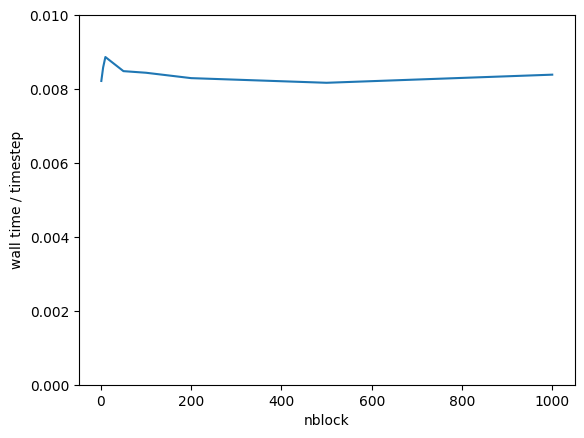

In [7]:
plt.plot(nbarr,resultarr[:,0])
plt.xlabel(r'nblock')
plt.ylabel(r'wall time / timestep')
plt.ylim(0,0.01)
